# MWE 13 - Synthetic porous-volume benchmark against XLB

This notebook generates synthetic segmented spanning volumes with `voids`, solves them directly
on the binary image with XLB, extracts pore networks with `snow2`, and compares `Kabs` estimates
between the direct-image voxel-scale LBM reference and the extracted-network PNM workflow.

Scientific scope and assumptions:
- the benchmark works on binary segmented images directly; it does not include scanner-physics
  emulation or a grayscale segmentation step
- the XLB side uses a stable lattice-unit pressure drop and converts only the permeability, not
  a fully pressure-calibrated physical transient
- the XLB solve adds short fluid reservoir layers ahead of and behind the sample so the imposed
  pressure boundary conditions live on clean planar faces rather than directly on a perforated
  porous inlet/outlet surface
- the `voids` side uses `snow2` extraction plus the selected hydraulic conductance model, so any
  mismatch reflects both extraction loss and PNM constitutive simplification
- side faces orthogonal to the flow axis are treated as sealed sample walls in the direct-image
  XLB solve, which matches the intended core-flood-style interpretation of the benchmark
- XLB is an optional dependency; run this notebook in the Pixi `lbm` environment

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from voids.benchmarks import XLBOptions, benchmark_segmented_volume_with_xlb
from voids.generators import generate_spanning_blobs_matrix
from voids.physics.singlephase import FluidSinglePhase, SinglePhaseOptions

In [2]:
flow_axis = "x"
axis_index = 0
voxel_size = 2.0e-6
fluid = FluidSinglePhase(viscosity=1.0e-3)
options = SinglePhaseOptions(
    conductance_model="valvatne_blunt_baseline",
    solver="direct",
)
xlb_options = XLBOptions(
    max_steps=2000,
    min_steps=400,
    check_interval=50,
    steady_rtol=1.0e-3,
    lattice_viscosity=0.10,
    rho_inlet=1.001,
    rho_outlet=1.000,
    inlet_outlet_buffer_cells=6,
)

case_specs = [
    {
        "case": "phi032_b14",
        "shape": (24, 24, 24),
        "porosity": 0.32,
        "blobiness": 1.4,
        "seed_start": 401,
    },
    {
        "case": "phi036_b16",
        "shape": (24, 24, 24),
        "porosity": 0.36,
        "blobiness": 1.6,
        "seed_start": 601,
    },
    {
        "case": "phi041_b14",
        "shape": (24, 24, 24),
        "porosity": 0.41,
        "blobiness": 1.4,
        "seed_start": 1301,
    },
]
case_specs

[{'case': 'phi032_b14',
  'shape': (24, 24, 24),
  'porosity': 0.32,
  'blobiness': 1.4,
  'seed_start': 401},
 {'case': 'phi036_b16',
  'shape': (24, 24, 24),
  'porosity': 0.36,
  'blobiness': 1.6,
  'seed_start': 601},
 {'case': 'phi041_b14',
  'shape': (24, 24, 24),
  'porosity': 0.41,
  'blobiness': 1.4,
  'seed_start': 1301}]

## Generate binary benchmark cases and compare `voids` against XLB

Each case is a percolating segmented void image. XLB sees the binary image directly, while `voids`
extracts a spanning pore network from the same image before solving.

In [3]:
benchmark_rows: list[dict[str, object]] = []
case_artifacts: dict[str, dict[str, object]] = {}

for case in case_specs:
    segmented, seed_used = generate_spanning_blobs_matrix(
        shape=case["shape"],
        porosity=case["porosity"],
        blobiness=case["blobiness"],
        axis_index=axis_index,
        seed_start=case["seed_start"],
        max_tries=30,
    )

    benchmark = benchmark_segmented_volume_with_xlb(
        segmented,
        voxel_size=voxel_size,
        flow_axis=flow_axis,
        fluid=fluid,
        options=options,
        xlb_options=xlb_options,
        provenance_notes={
            "benchmark_case": case["case"],
            "seed_used": seed_used,
        },
    )

    record = benchmark.to_record()
    benchmark_rows.append(
        {
            **case,
            "seed_used": int(seed_used),
            **record,
            "k_ratio_voids_to_xlb": float(record["k_voids"]) / float(record["k_xlb"]),
            "k_rel_diff_pct": 100.0 * float(record["k_rel_diff"]),
        }
    )
    case_artifacts[case["case"]] = {
        "segmented": segmented,
        "benchmark": benchmark,
    }

summary_df = pd.DataFrame(benchmark_rows)
display_columns = [
    "case",
    "seed_used",
    "shape",
    "porosity",
    "blobiness",
    "phi_image",
    "phi_abs",
    "phi_eff",
    "Np",
    "Nt",
    "k_voids",
    "k_xlb",
    "k_rel_diff",
    "k_ratio_voids_to_xlb",
    "xlb_steps",
    "xlb_converged",
    "xlb_convergence_metric",
]
summary_df.loc[:, display_columns]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Warp DeprecationWarning: The symbol `warp.utils.ScopedTimer` will soon be removed from the public API. Use `warp.ScopedTimer` instead.
No GPU support is available; CPU fallback will be used.
registered bc RegularizedBC_932734950 with id 1
registered bc RegularizedBC_932734947 with id 2
registered bc HalfwayBounceBackBC_932734962 with id 3
No GPU support is available; CPU fallback will be used.
registered bc RegularizedBC_937479248 with id 4
registered bc RegularizedBC_932685066 with id 5
registered bc HalfwayBounceBackBC_937487491 with id 6
No GPU support is available; CPU fallback will be used.
registered bc RegularizedBC_954367032 with id 7
registered bc RegularizedBC_946732268 with id 8
registered bc HalfwayBounceBackBC_954358209 with id 9


,case,seed_used,shape,porosity,blobiness,phi_image,phi_abs,phi_eff,Np,Nt,k_voids,k_xlb,k_rel_diff,k_ratio_voids_to_xlb,xlb_steps,xlb_converged,xlb_convergence_metric
0,phi032_b14,401,"(24, 24, 24)",0.32,1.4,0.320023,0.319517,0.319517,38,77,6.756270e-14,-8.165579e-17,1.001209,-827.408566,350,True,0.000311
1,phi036_b16,601,"(24, 24, 24)",0.36,1.6,0.360026,0.359954,0.359954,22,49,3.924042e-14,-8.993610e-17,1.002292,-436.314451,300,True,0.000800
2,phi041_b14,1301,"(24, 24, 24)",0.41,1.4,0.410012,0.410012,0.410012,24,58,9.748821e-14,-5.836004e-17,1.000599,-1670.461675,300,True,0.000218


## Representative binary slice and XLB axial-velocity field

The XLB result retains the axial lattice velocity field, which lets us inspect whether the
direct-image reference solution is well aligned with the segmented geometry.

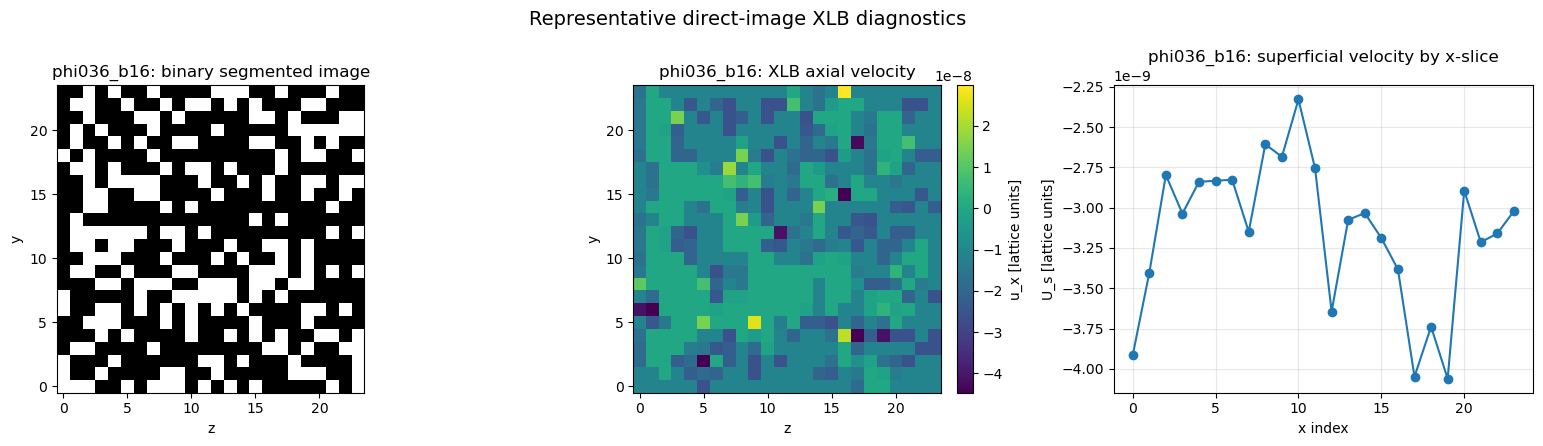

Representative XLB converged: True
Representative XLB steps: 300
Representative XLB convergence metric: 0.0007995481491791654


In [4]:
representative_case = "phi036_b16"
artifact = case_artifacts[representative_case]
segmented = artifact["segmented"]
benchmark = artifact["benchmark"]
axial_velocity = benchmark.xlb_result.axial_velocity_lattice
mid = segmented.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].imshow(segmented[mid, :, :], cmap="gray", origin="lower")
axes[0].set_title(f"{representative_case}: binary segmented image")
axes[0].set_xlabel("z")
axes[0].set_ylabel("y")

im = axes[1].imshow(axial_velocity[mid, :, :], cmap="viridis", origin="lower")
axes[1].set_title(f"{representative_case}: XLB axial velocity")
axes[1].set_xlabel("z")
axes[1].set_ylabel("y")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="u_x [lattice units]")

axes[2].plot(
    benchmark.xlb_result.superficial_velocity_profile_lattice,
    marker="o",
    lw=1.5,
)
axes[2].set_title(f"{representative_case}: superficial velocity by x-slice")
axes[2].set_xlabel("x index")
axes[2].set_ylabel("U_s [lattice units]")
axes[2].grid(True, alpha=0.3)

fig.suptitle("Representative direct-image XLB diagnostics", fontsize=14)
plt.tight_layout()
plt.show()

print("Representative XLB converged:", benchmark.xlb_result.converged)
print("Representative XLB steps:", benchmark.xlb_result.n_steps)
print("Representative XLB convergence metric:", benchmark.xlb_result.convergence_metric)

## Permeability comparison

Agreement is not expected to be exact here: the direct-image XLB solve resolves the segmented
pore space voxel-by-voxel, while `voids` first compresses that geometry into an extracted network
and then uses the selected pore-network conductance model.

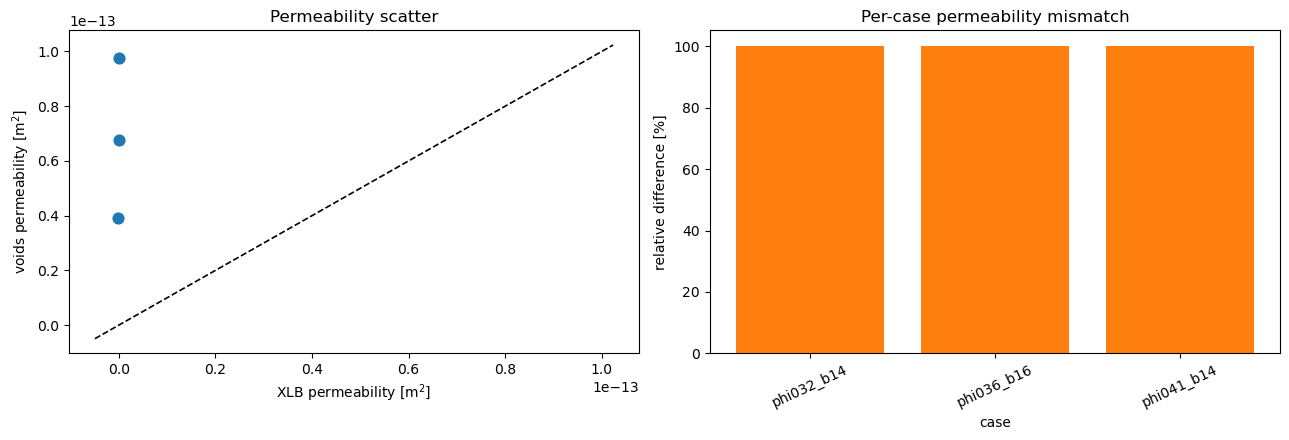

,case,k_voids,k_xlb,k_rel_diff_pct,xlb_steps,xlb_converged
0,phi032_b14,6.756270e-14,-8.165579e-17,100.120859,350,True
1,phi036_b16,3.924042e-14,-8.993610e-17,100.229193,300,True
2,phi041_b14,9.748821e-14,-5.836004e-17,100.059864,300,True


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

kmin = float(min(summary_df["k_voids"].min(), summary_df["k_xlb"].min()))
kmax = float(max(summary_df["k_voids"].max(), summary_df["k_xlb"].max()))
pad = 0.05 * max(kmax - kmin, 1.0e-30)

axes[0].scatter(summary_df["k_xlb"], summary_df["k_voids"], s=60, color="tab:blue")
axes[0].plot(
    [kmin - pad, kmax + pad],
    [kmin - pad, kmax + pad],
    color="black",
    lw=1.2,
    linestyle="--",
)
axes[0].set_xlabel("XLB permeability [m$^2$]")
axes[0].set_ylabel("voids permeability [m$^2$]")
axes[0].set_title("Permeability scatter")

axes[1].bar(summary_df["case"], summary_df["k_rel_diff_pct"], color="tab:orange")
axes[1].set_xlabel("case")
axes[1].set_ylabel("relative difference [%]")
axes[1].set_title("Per-case permeability mismatch")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

summary_df.loc[
    :, ["case", "k_voids", "k_xlb", "k_rel_diff_pct", "xlb_steps", "xlb_converged"]
]

## Notes

Useful follow-up checks if the mismatch is larger than expected:

- tighten XLB convergence controls (`max_steps`, `check_interval`, `steady_rtol`)
- inspect whether the segmented geometry is too coarse for the direct-image solve
- compare against multiple conductance models on the `voids` side
- repeat on larger synthetic samples to reduce inlet/outlet and discretization effects